In [19]:
#import all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [20]:
#load the dataset
data=pd.read_csv('car data.csv')
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [21]:
#printing the basic information of the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [22]:
#statistical description of the dataset
data.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [23]:
#print sum of null values
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Exploratory Data Analysis

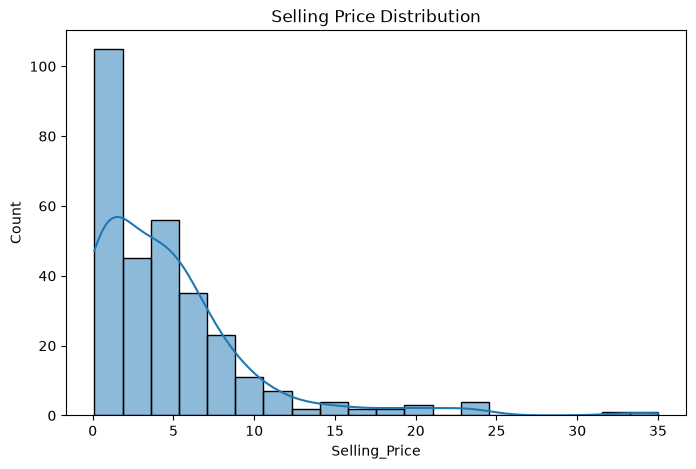

In [24]:
#plot histogram for selling price distribution
plt.figure(figsize=(8,5))
sns.histplot(data['Selling_Price'],bins=20,kde=True)
plt.title("Selling Price Distribution")
plt.show()

In [25]:
#encoding all the string data type to train the model
encoder=LabelEncoder()

data['Fuel_Type']=encoder.fit_transform(data['Fuel_Type'])
data['Transmission']=encoder.fit_transform(data['Transmission'])
data['Car_Name']=encoder.fit_transform(data['Car_Name'])
data['Selling_type']=encoder.fit_transform(data['Selling_type'])

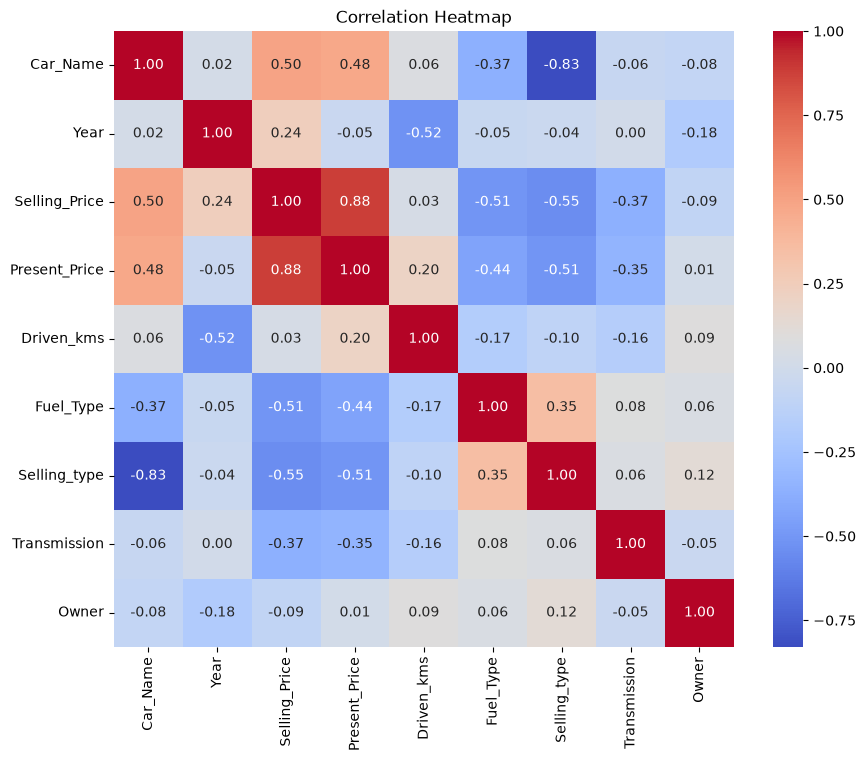

In [26]:
#select only integer and float columns
numeric_df=data.select_dtypes(include=['int64', 'float64'])

#correlation matrix
corr_matrix=numeric_df.corr()

#plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [27]:
#defining input features and label
x=data.drop(['Selling_Price', 'Car_Name'], axis=1)
y=data['Selling_Price']

In [11]:
#defining training and testing dataset
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
#training the random forest model
rf=RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)
rf_pred=rf.predict(x_test)

In [29]:
#printing errors
print("MAE :",mean_absolute_error(y_test,rf_pred))
print("MSE :",mean_squared_error(y_test,rf_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,rf_pred)))
print("R2 Score :",r2_score(y_test,rf_pred))

MAE : 0.6136655737704918
MSE : 0.8386252459016387
RMSE : 0.9157648420318606
R2 Score : 0.963594357887339


In [ ]:
#accuracy of the model
accuracy=r2_score(y_test,rf_pred)*100
print("Model Accuracy :",accuracy)

Model Accuracy : 96.3594357887339


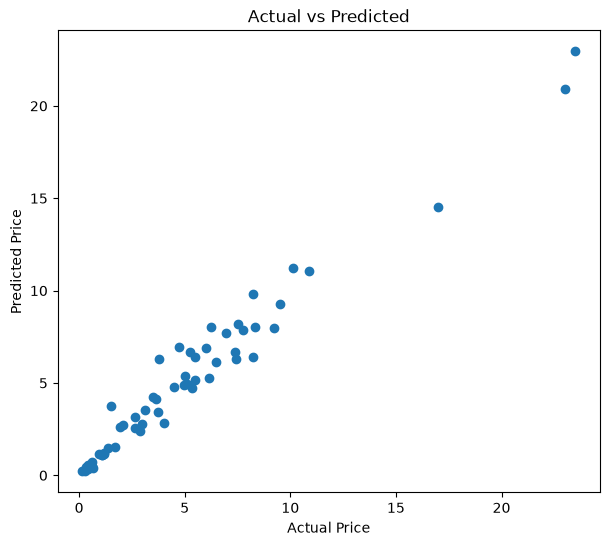

In [30]:
#plot scatter plot to analyse actual vs predicted price
plt.figure(figsize=(7,6))
plt.scatter(y_test,rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

Above scatter plot shows us there is a strong positive correlation between actual price and the predicted price. It shows good prediction accuracy.
There are no major outliers and there are only few cars with very high selling prices(around 15-20 lakhs).

In [31]:
#load the model
import pickle
pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(encoder, open("encoder.pkl", "wb"))

In [32]:
#label encoding
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

print("Fuel_Type:")
print(dict(zip(
    encoder.fit(data["Fuel_Type"]).classes_,
    encoder.transform(encoder.classes_)
)))

print("\nSelling_type:")
print(dict(zip(
    encoder.fit(data["Selling_type"]).classes_,
    encoder.transform(encoder.classes_)
)))

print("\nTransmission:")
print(dict(zip(
    encoder.fit(data["Transmission"]).classes_,
    encoder.transform(encoder.classes_)
)))

Fuel_Type:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}

Selling_type:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Transmission:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
